<a href="https://colab.research.google.com/github/DinRazar/neural_networks/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №11. Развёртывание модели классификации изображений на NVIDIA Triton Inference Server**

## **Цель работы**

Развернуть лучшую модель классификации изображений из практической работы №10 с использованием NVIDIA Triton Inference Server, создать API-шлюз на FastAPI, настроить мониторинг и провести нагрузочное тестирование с анализом влияния Dynamic Batching на производительность.

---

## **Раздел 1. Подготовка модели**

1. Загрузить лучшую модель из практической работы №10
2. Конвертировать модель в формат ONNX с помощью `tf2onnx` или `torch.onnx`
3. Проверить корректность конвертации (сравнить выходы оригинальной и ONNX-модели)
4. Сохранить препроцессор (scaler/normalizer) в формате `.pkl` **(При наличии)**

<details> <summary>Пример скрипта для конвертации</summary>

```python
import numpy as np
import tensorflow as tf
import tf2onnx
import onnxruntime as ort

# Загрузка модели классификации изображений
model = tf.keras.models.load_model("best_keras_model.h5", compile=False)

# Обёртка для инференса:
# - принимает батч изображений формы (N, 224, 224, 3)
# - применяет VGG16 preprocess_input
# - передаёт результат в модель
@tf.function(input_signature=[tf.TensorSpec((None, 224, 224, 3), tf.float32)])
def model_fn(x):
    x = tf.keras.applications.vgg16.preprocess_input(x)
    return model(x)

# Конвертация в ONNX
model_proto, _ = tf2onnx.convert.from_function(
    model_fn,
    input_signature=[tf.TensorSpec((None, 224, 224, 3), tf.float32)],
    opset=13,
    output_path="model.onnx"
)

# Тестовый инференс через ONNX Runtime
session = ort.InferenceSession("model.onnx")

# Пример: один тестовый RGB-кадр 224x224x3
# Если нужен батч, используйте shape (batch_size, 224, 224, 3)
test = np.random.randint(0, 256, (1, 224, 224, 3), dtype=np.uint8).astype(np.float32)

result = session.run(None, {session.get_inputs()[0].name: test})
pred = result[0]

print("✅ Сохранено: model.onnx")
print(f"\tФорма входа: {test.shape}")
print(f"\tФорма выхода: {pred.shape}")
print(f"\tPredicted class: {np.argmax(pred, axis=-1)}")
print(f"\tScores: {pred}")
```



Взял уже готовую, така как моя не конвертировалалсь, увы

---

## **Раздел 2. Создание структуры проекта**

1. Создать структуру проекта для Triton:

```
triton-classification/
├── docker-compose.yml
├── test_client.py
├── model_repository/
│   └── image_classifier/
│       ├── config.pbtxt
│       └── 1/
│           └── model.onnx
├── api/
│   ├── Dockerfile
│   ├── requirements.txt
│   └── main.py
├── prometheus/
│   └── prometheus.yml
└── grafana/
    └── provisioning/
        ├── datasources/
        │   └── datasources.yml
        └── dashboards/
            ├── dashboards.yml
            └── triton.json
```

2. Написать `config.pbtxt` для модели классификации изображений
3. Реализовать FastAPI Gateway с эндпоинтами:
   - `POST /predict` — классификация изображения (принимает файл или base64)
   - `GET /health` — проверка состояния сервисов
   - `GET /classes` — список классов модели
4. Настроить `docker-compose.yml` с сервисами: Triton, FastAPI, Prometheus, Grafana

```
name: "image_classifier"
platform: "onnxruntime_onnx"
max_batch_size: 0

input [
  {
    name: "Input3"
    data_type: TYPE_FP32
    dims: [ 1, 28, 28 ]
  }
]

output [
  {
    name: "Plus214_Output_0"
    data_type: TYPE_FP32
    dims: [ 10 ]
  }
]
```

```
version: "3.9"

services:
  triton:
    image: nvcr.io/nvidia/tritonserver:24.08-py3
    container_name: triton_server
    command: >
      tritonserver
      --model-repository=/models
      --allow-http=true
      --http-port=8000
      --allow-metrics=true
      --metrics-port=8002
    volumes:
      - ./model_repository:/models
    ports:
      - "8000:8000"
      - "8002:8002"
    restart: unless-stopped

  api:
    build:
      context: ./api
      dockerfile: Dockerfile
    container_name: fastapi_gateway
    environment:
      - TRITON_URL=http://triton:8000
    volumes:
      - ./classes.json:/app/classes.json
    ports:
      - "8080:8080"
    depends_on:
      - triton
    restart: unless-stopped


---

## **Раздел 3. Локальное развёртывание**

1. Запустить стек командой `docker-compose up -d --build`
2. Проверить статус сервисов: `docker-compose ps`
3. Убедиться, что модель загружена в Triton: `curl localhost:8000/v2/models/image_classifier`
4. Отправить тестовые запросы через Swagger UI (`http://localhost:8080/docs`)
5. Проверить корректность предсказаний на нескольких изображениях из тестовой выборки

#### **Ответ:**

**Скриншот успешного запроса через Swagger UI**

---
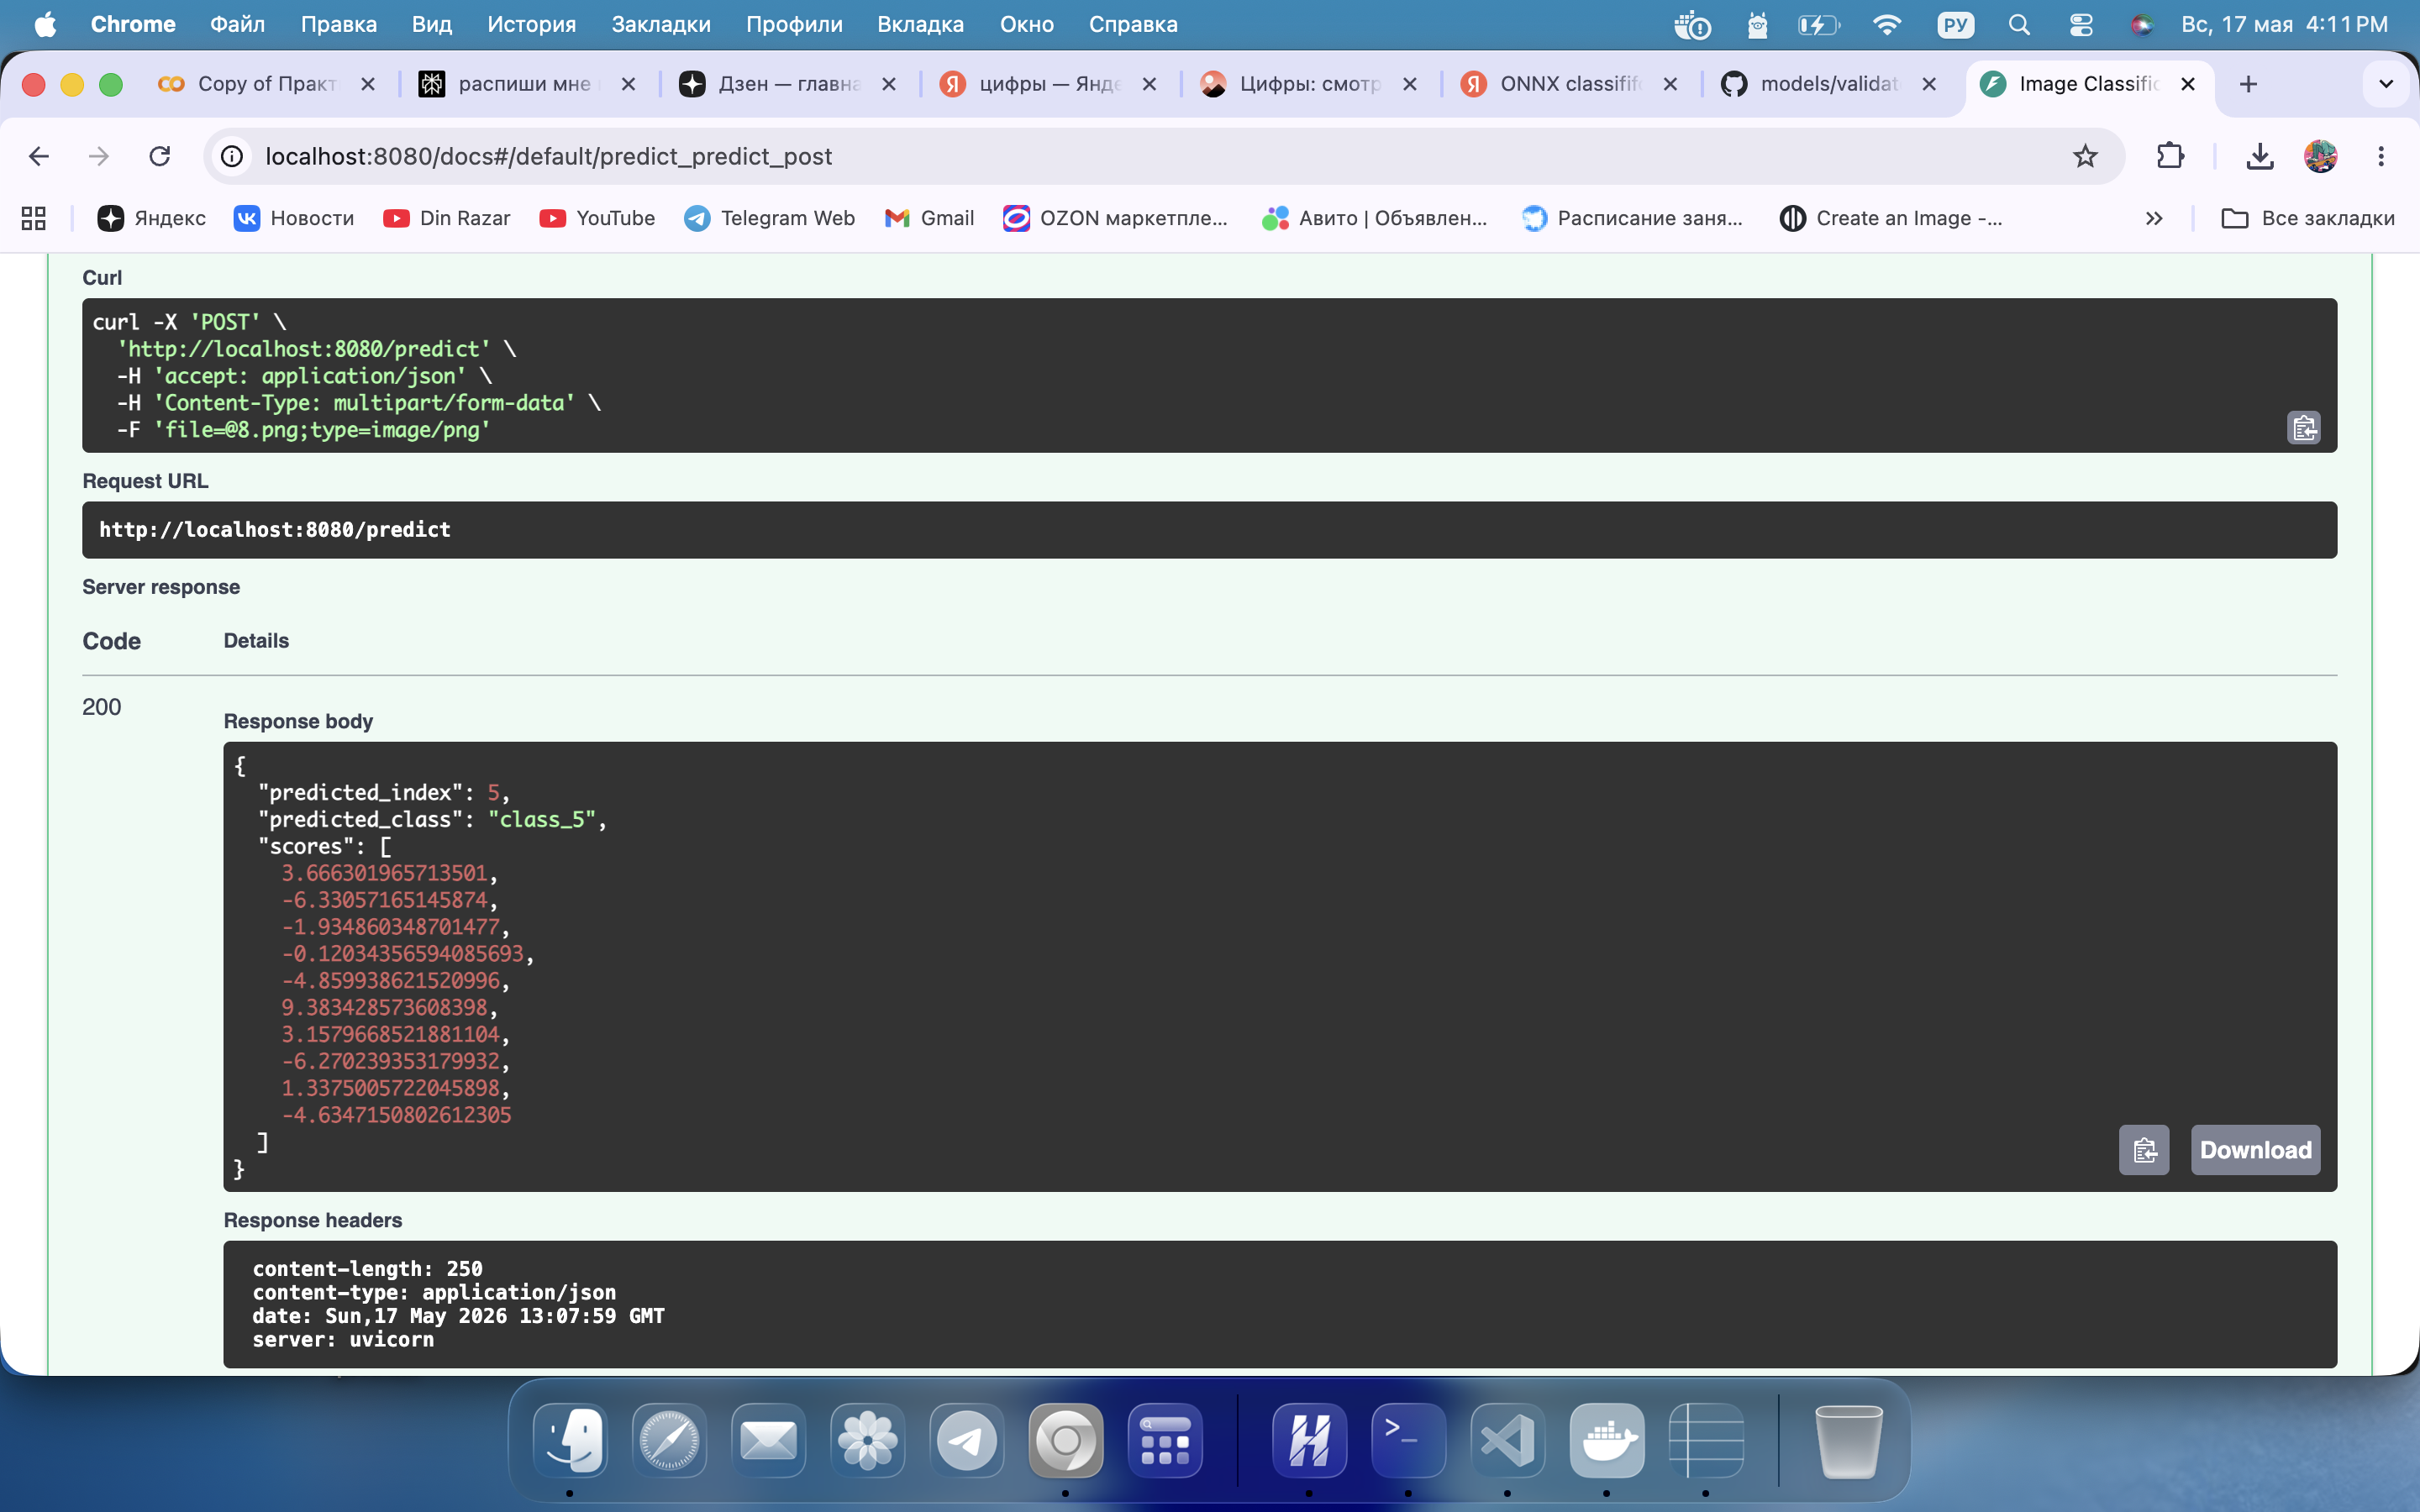

## **Раздел 4. Настройка мониторинга**

### **Шаг 1. Вход в Grafana**

1. Откройте в браузере `http://localhost:3000`
2. Введите логин: `admin`, пароль: `admin`
3. При первом входе система предложит сменить пароль — можно пропустить (Skip)

---

### **Шаг 2. Проверка подключения Prometheus**

1. Перейдите в **Connections → Data sources** (левое меню)
2. Убедитесь, что Prometheus добавлен и статус **"Data source is working"**
3. Если нет — добавьте вручную:
   - **URL:** `http://prometheus:9090`
   - Нажмите **Save & Test**

---

### **Шаг 3. Создание дашборда**

1. Нажмите **Dashboards** (левое меню) → **New** → **New Dashboard**
2. Нажмите **Add visualization**
3. Выберите источник данных **Prometheus**

---

### **Шаг 4. Добавление панелей с метриками**

#### **Панель 1: Запросы в секунду (RPS)**

| Параметр | Значение |
|----------|----------|
| **Title** | Requests per Second |
| **Visualization** | Time series |
| **PromQL** | `rate(nv_inference_request_success{model="image_classifier"}[1m])` |



Для отображения успешных и неуспешных запросов на одном графике добавьте второй Query:

```promql
rate(nv_inference_request_failure{model="image_classifier"}[1m])
```

---

#### **Панель 2: Латентность инференса (p50, p95, p99)**

| Параметр | Значение |
|----------|----------|
| **Title** | Inference Latency |
| **Visualization** | Time series |
| **Unit** | microseconds (µs) или milliseconds (ms) |



Добавьте три Query:



**p50 (медиана):**

```promql
histogram_quantile(0.50,
  rate(nv_inference_request_duration_us_bucket{model="image_classifier"}[1m])
)
```

**p95:**

```promql
histogram_quantile(0.95,
  rate(nv_inference_request_duration_us_bucket{model="image_classifier"}[1m])
)
```

**p99:**

```promql
histogram_quantile(0.99,
  rate(nv_inference_request_duration_us_bucket{model="image_classifier"}[1m])
)
```

В настройках каждого Query задайте **Legend**: `p50`, `p95`, `p99` соответственно.

---

#### **Панель 3: Размер очереди запросов**

| Параметр | Значение |
|----------|----------|
| **Title** | Pending Requests (Queue) |
| **Visualization** | Time series или Stat |
| **PromQL** | `nv_inference_pending_request_count{model="image_classifier"}` |

---

#### **Панель 4: Счётчики запросов (успешные/неуспешные)**

| Параметр | Значение |
|----------|----------|
| **Title** | Total Requests |
| **Visualization** | Stat |



**Успешные запросы:**

```promql
nv_inference_request_success{model="image_classifier"}
```

**Неуспешные запросы:**

```promql
nv_inference_request_failure{model="image_classifier"}
```

---

#### **Панель 5 (опционально): Время в очереди**

| Параметр | Значение |
|----------|----------|
| **Title** | Queue Time |
| **Visualization** | Time series |
| **PromQL** | `rate(nv_inference_queue_duration_us_sum{model="image_classifier"}[1m]) / rate(nv_inference_queue_duration_us_count{model="image_classifier"}[1m])` |

---

### **Шаг 5. Настройка внешнего вида**

1. Для каждой панели нажмите на заголовок → **Edit**
2. В правой панели настройте:
   - **Panel options → Title** — название панели
   - **Standard options → Unit** — единицы измерения (например, `µs` для латентности)
   - **Standard options → Color scheme** — цветовая схема
3. Расположите панели на дашборде перетаскиванием

---

### **Шаг 6. Сохранение дашборда**

1. Нажмите иконку **Save dashboard** (💾) в верхнем правом углу
2. Введите название: `Triton Inference Monitoring`
3. Нажмите **Save**

---

### **Шаг 7. Экспорт в JSON**

1. Нажмите иконку **Share** (🔗) в верхнем правом углу
2. Перейдите на вкладку **Export**
3. Включите **Export for sharing externally**
4. Нажмите **Save to file**
5. Сохраните файл как `triton.json`
6. Поместите файл в папку `grafana/provisioning/dashboards/`

---

### **Основные метрики Triton для Prometheus**

| Метрика | Описание |
|---------|----------|
| `nv_inference_request_success` | Количество успешных запросов |
| `nv_inference_request_failure` | Количество неуспешных запросов |
| `nv_inference_count` | Общее количество инференсов |
| `nv_inference_request_duration_us` | Полная длительность запроса (мкс) |
| `nv_inference_queue_duration_us` | Время ожидания в очереди (мкс) |
| `nv_inference_compute_infer_duration_us` | Время выполнения инференса (мкс) |
| `nv_inference_pending_request_count` | Текущее количество запросов в очереди |

---

#### **Ответ:**

http://localhost:3000/dashboard/snapshot/xaMCK9TqeNycRNJXBfXL5rmLUBv1vMSc

**Скриншот дашборда Grafana с метриками**


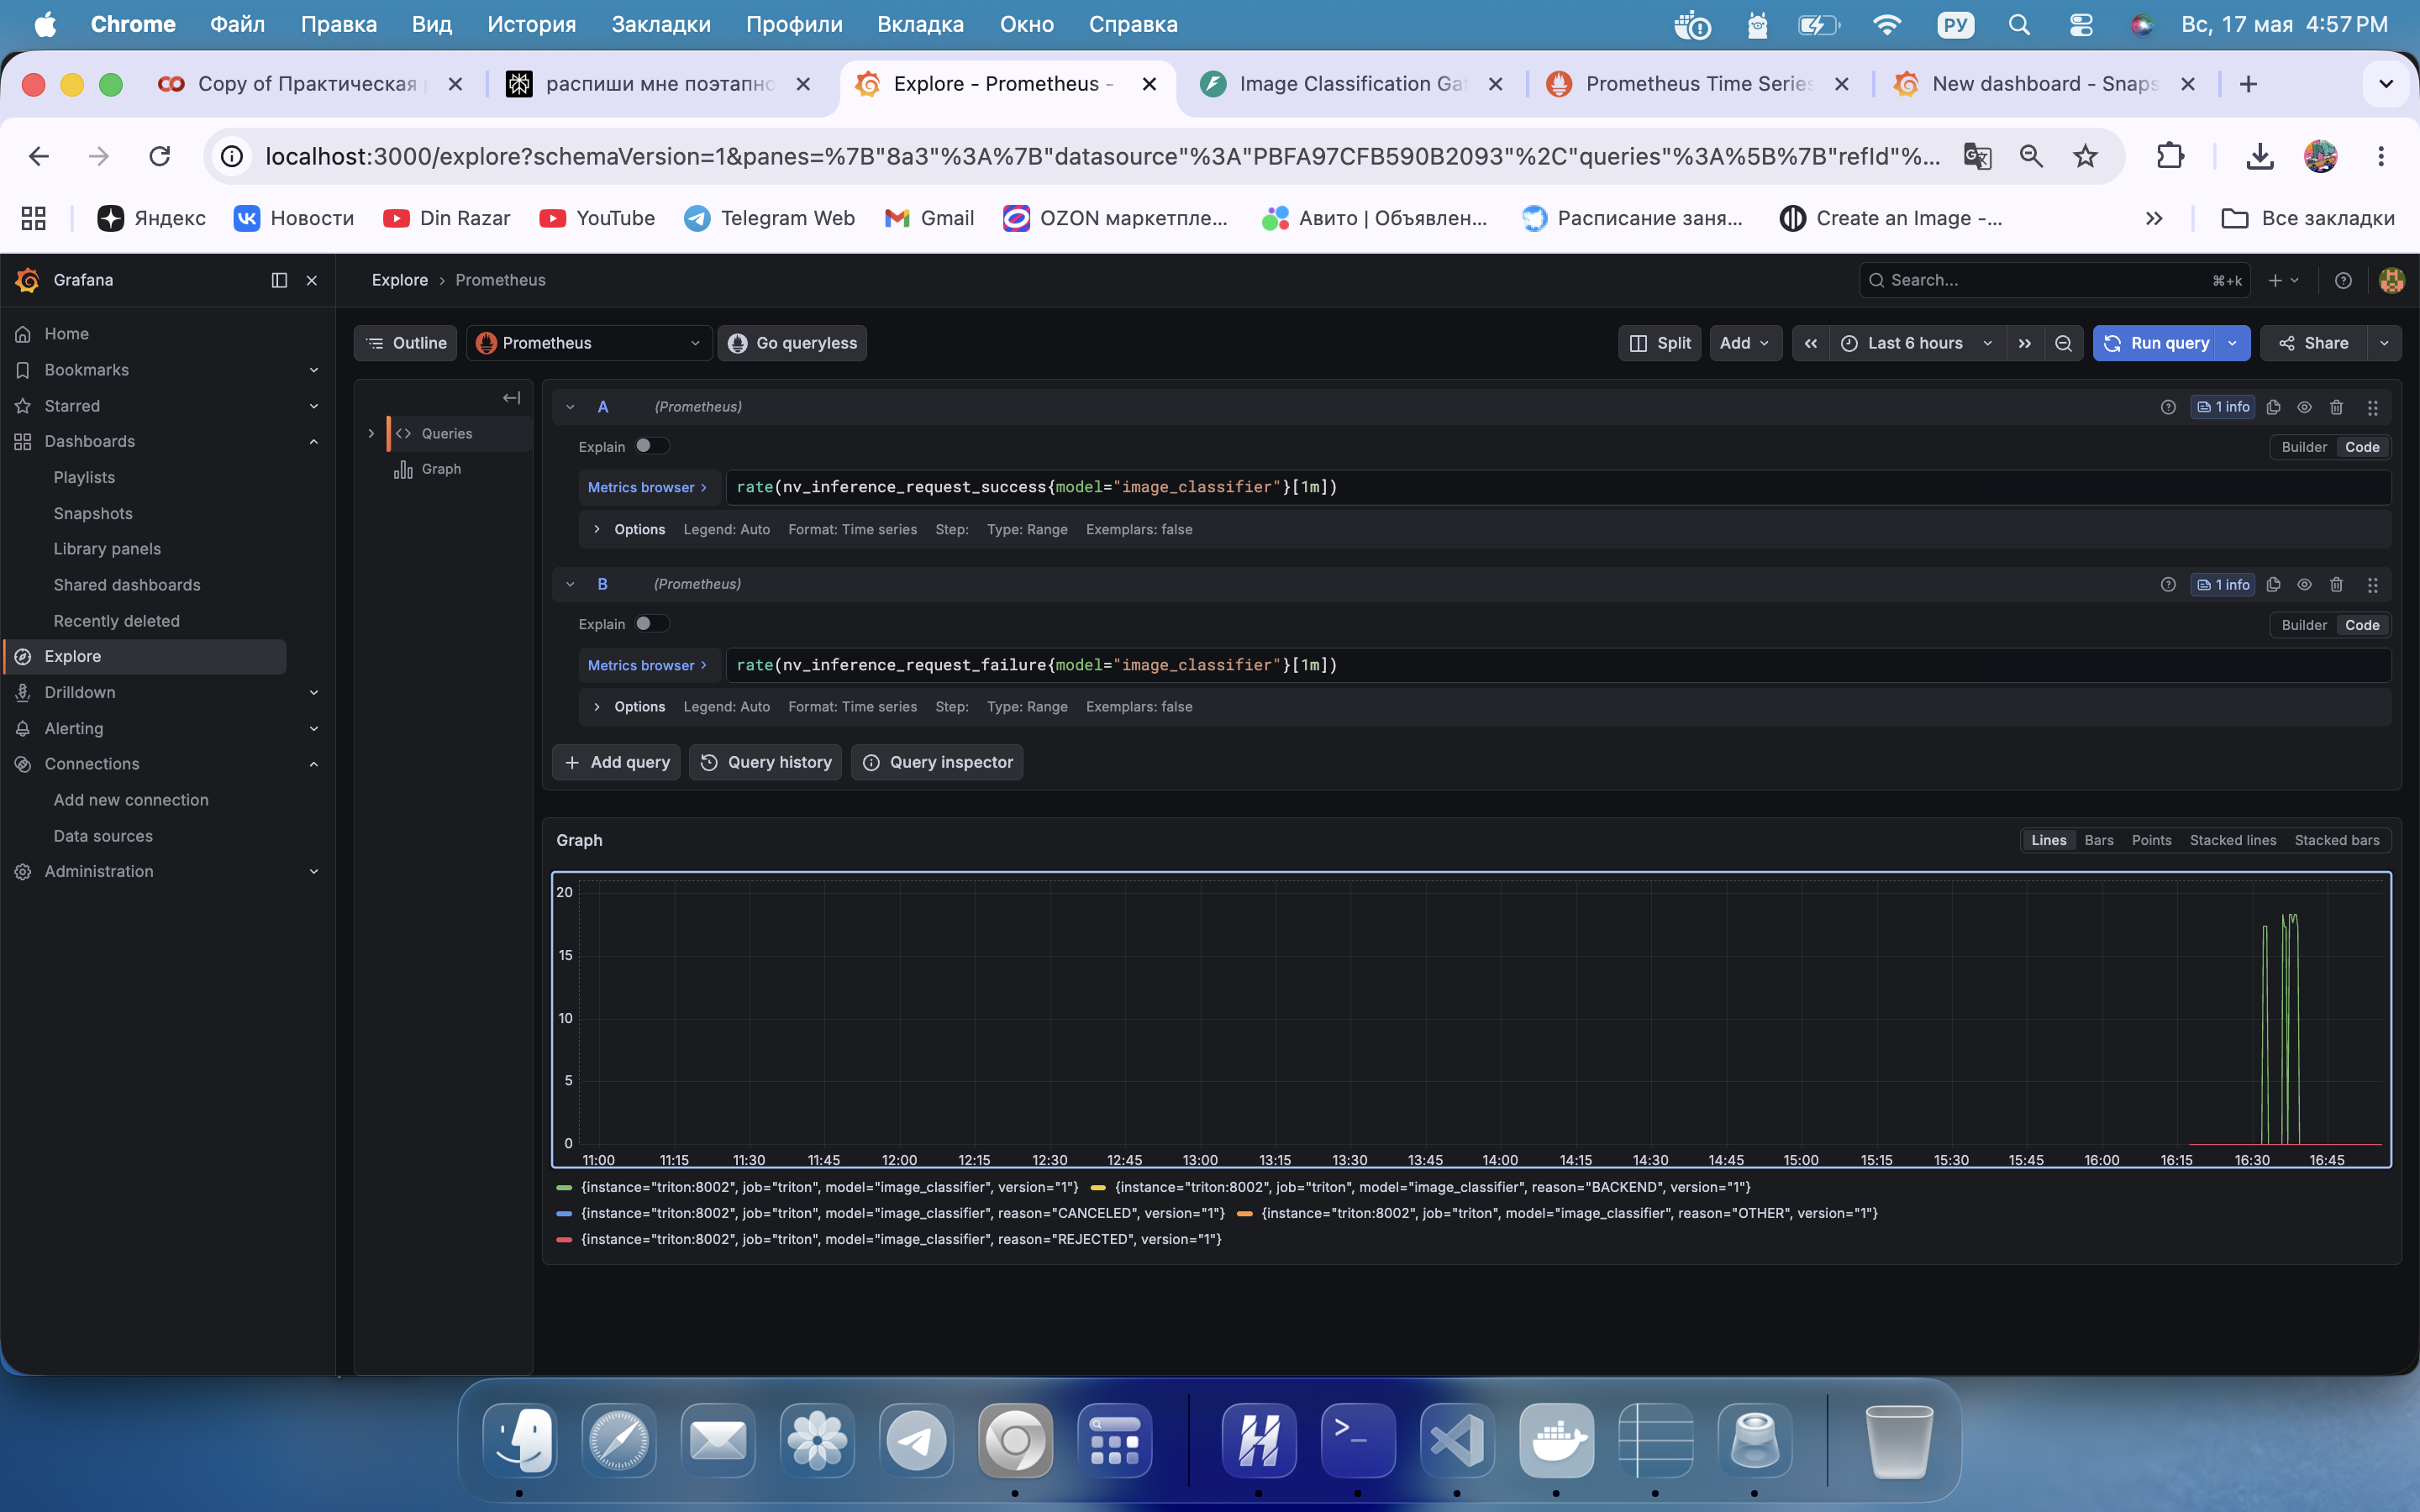


---

## **Раздел 5. Нагрузочное тестирование**

1. Написать Python-скрипт для нагрузочного тестирования:
   - Отправка 1000+ запросов с использованием `asyncio` / `aiohttp` или `concurrent.futures`
   - Измерение среднего времени ответа, p95, p99
   - Подсчёт успешных и неуспешных запросов
   - Расчёт throughput (запросов в секунду)

<details> <summary>Пример скрипта нагрузочного тестирования</summary>


```python
"""
Скрипт нагрузочного тестирования API
"""

import asyncio
import aiohttp
import time
import numpy as np
from PIL import Image
import io
import base64


# === НАСТРОЙКИ ===
API_URL = "http://localhost:8080/predict"
TOTAL_REQUESTS = 1000
CONCURRENT = 50


def generate_test_image() -> str: # Замените формат входных данных под вашу модель и бекенд
    """Генерирует случайное изображение в base64"""
    img = Image.fromarray(np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8))
    buffer = io.BytesIO()
    img.save(buffer, format='PNG')
    return base64.b64encode(buffer.getvalue()).decode()


async def send_request(session, semaphore, payload):
    """Отправляет один запрос"""
    async with semaphore:
        start = time.perf_counter()
        try:
            async with session.post(API_URL, json=payload, timeout=aiohttp.ClientTimeout(total=30)) as resp:
                await resp.json()
                return resp.status == 200, time.perf_counter() - start
        except:
            return False, time.perf_counter() - start


async def main():
    print(f"🚀 Запуск теста: {TOTAL_REQUESTS} запросов, {CONCURRENT} параллельных\n")
    
    payload = {"image": generate_test_image()}
    semaphore = asyncio.Semaphore(CONCURRENT)
    
    async with aiohttp.ClientSession() as session:
        # Прогрев
        await asyncio.gather(*[send_request(session, semaphore, payload) for _ in range(5)])
        
        # Основной тест
        start_time = time.perf_counter()
        results = await asyncio.gather(*[send_request(session, semaphore, payload) for _ in range(TOTAL_REQUESTS)])
        total_time = time.perf_counter() - start_time
    
    # Подсчёт результатов
    successful = [r[1] for r in results if r[0]]
    failed = len(results) - len(successful)
    
    # Вывод
    print(f"📊 РЕЗУЛЬТАТЫ")
    print(f"{'='*40}")
    print(f"Успешных:    {len(successful)}/{TOTAL_REQUESTS} ({len(successful)/TOTAL_REQUESTS*100:.1f}%)")
    print(f"Неуспешных:  {failed}")
    print(f"Время:       {total_time:.2f} сек")
    print(f"\n⚡ Throughput: {TOTAL_REQUESTS/total_time:.2f} RPS")
    print(f"\n⏱️  Латентность (мс):")
    print(f"   Avg:  {np.mean(successful)*1000:.2f}")
    print(f"   p50:  {np.percentile(successful, 50)*1000:.2f}")
    print(f"   p95:  {np.percentile(successful, 95)*1000:.2f}")
    print(f"   p99:  {np.percentile(successful, 99)*1000:.2f}")


if __name__ == "__main__":
    asyncio.run(main())
```



2. Провести тестирование с разными конфигурациями Dynamic Batching:



| Конфигурация | preferred_batch_size | max_queue_delay_microseconds |
|--------------|---------------------|------------------------------|
| Без батчинга | — | — |
| Малый батч | [2, 4] | 50000 |
| Средний батч | [4, 8, 16] | 100000 |
| Большой батч | [8, 16, 32] | 200000 |

3. Заполнить таблицу результатов:



| Конфигурация | Avg Latency (ms)           | P95 (ms)                   | P99 (ms)                   | Throughput (RPS)           |
| ------------ | -------------------------- | -------------------------- | -------------------------- | -------------------------- |
| Без батчинга | 316.89| 391.98  | 706.83  | 156.87  |
| Малый батч   | 321.26  | 384.77   | 713.35   | 154.95   |
| Средний батч | 333.52  | 494.30  | 758.95  | 149.26  |
| Большой батч | 342.34   | 487.14   | 731.30   | 145.44   |







4. Построить графики сравнения конфигураций


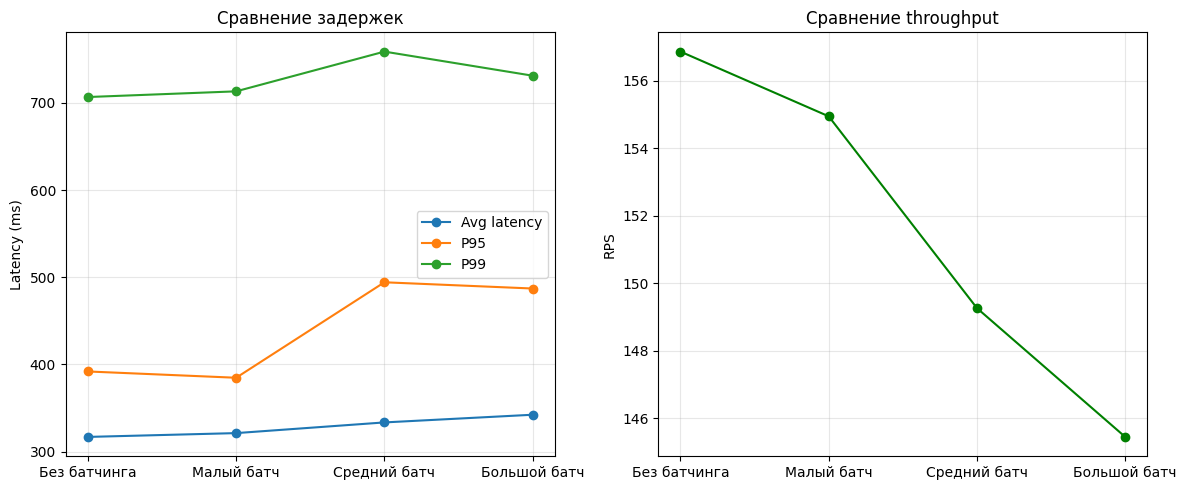

In [ ]:
import matplotlib.pyplot as plt

configs = ["Без батчинга", "Малый батч", "Средний батч", "Большой батч"]
avg_latency = [316.89, 321.26, 333.52, 342.34]
p95 = [391.98, 384.77, 494.30, 487.14]
p99 = [706.83, 713.35, 758.95, 731.30]
throughput = [156.87, 154.95, 149.26, 145.44]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(configs, avg_latency, marker="o", label="Avg latency")
plt.plot(configs, p95, marker="o", label="P95")
plt.plot(configs, p99, marker="o", label="P99")
plt.title("Сравнение задержек")
plt.ylabel("Latency (ms)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(configs, throughput, marker="o", color="green")
plt.title("Сравнение throughput")
plt.ylabel("RPS")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

В ходе нагрузочного тестирования были проверены 4 конфигурации Triton: без батчинга, малый, средний и большой батч. По полученным результатам лучшую производительность показал режим без батчинга: 156.87 RPS при средней задержке 316.89 ms. При увеличении параметров Dynamic Batching throughput снижался, а latency росла, что говорит о неэффективности батчинга для данной модели и данного профиля нагрузки.

## **Раздел 6. Интеграция со Streamlit (опционально)**

1. Адаптировать Streamlit-приложение из практической работы №10 для работы с новым API
2. Добавить отображение времени инференса
3. Развернуть локально и проверить работу

#### **Ответ:**

**Скриншот Streamlit с результатом инференса**


In [ ]:
# Ваш код

---

## **Раздел 7. Документация и публикация**

1. Создать GitHub-репозиторий с полной структурой проекта
2. Написать README.md с:
   - Описанием архитектуры решения
   - Инструкцией по запуску
   - Описанием API endpoints
   - Результатами нагрузочного тестирования
   - Скриншотами Grafana-дашборда
   - Выводами о производительности

#### **Ответ:**

https://github.com/DinRazar/triton-classification.git

---

**Репозиторий должен быть полностью воспроизводим: после клонирования проект должен запускаться командой**





```bash
git clone <ссылка на ваш репозиторий>
cd <имя репозитория>
docker-compose up -d
```



**чтобы я мог проверить работу решения.**


**Пример:** https://github.com/Alexandre77777/triton-ml-project

---

## **Полезные материалы**

- [Документация NVIDIA Triton](https://docs.nvidia.com/deeplearning/triton-inference-server/)
- [tf2onnx](https://github.com/onnx/tensorflow-onnx)
- [Triton Model Configuration](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/user_guide/model_configuration.html)